<h1><center>MS BGD - TP Avazu<center></h1>


# André Santos Rocha

# Introduction

In online advertising, click-through rate (CTR) is a very important metric for evaluating ad performance. As a result, click prediction systems are essential and widely used for sponsored search and real-time bidding. The goal of this TP is to build and test prediction models on 11 days of Avazu data.



In [1]:
import sys
from zipfile import ZipFile
import os.path as op
try:
    from urllib.request import urlretrieve
except ImportError:  # Python 2 compat
    from urllib import urlretrieve

AVAZU_URL = "https://bianchi.wp.imt.fr/files/2019/05/train-1000000.zip"
AVAZU_FILENAME = AVAZU_URL.rsplit('/', 1)[1]


if not op.exists(AVAZU_FILENAME):
    print('Downloading %s to %s...' % (AVAZU_URL, AVAZU_FILENAME))
    urlretrieve(AVAZU_URL, AVAZU_FILENAME)
    print('Extracting to %s...' % AVAZU_FILENAME)
    ZipFile(AVAZU_FILENAME).extractall('.')

Extracting to train-1000000.zip...


<font color="red">**Question:**
    Import the needed packages: numpy, pandas etc..
</font>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
%matplotlib inline

# The dataset

<font color="red">**Question:**
Load the data *'train-1000000'* into a pandas DataFrame. Then, display the first lines with the ".head()" method.
</font>
**Remark**: the features meaning is available at https://www.kaggle.com/c/avazu-ctr-prediction/data

In [3]:
df = pd.read_csv('train-1000000')

In [4]:
df.head()

,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,3.983206e+18,0,14102915,1005,1,e151e245,7e091613,f028772b,ecad2386,7801e8d9,...,1,2,4687,320,50,423,2,39,100148,32
1,7.756884e+18,0,14103007,1002,0,cb809abf,74acf31a,50e219e0,ecad2386,7801e8d9,...,0,0,17894,320,50,2039,2,39,100077,32
2,6.941774e+17,0,14102711,1005,0,85f751fd,c4e18dd6,50e219e0,e9739828,df32afa9,...,1,0,22684,320,50,2619,1,163,100055,71
3,2.664154e+18,1,14102903,1005,0,85f751fd,c4e18dd6,50e219e0,a5184c22,b8d325c3,...,1,0,23222,320,50,2676,0,35,100176,221
4,1.480510e+19,0,14102902,1005,1,791b5571,fd13bc73,f028772b,ecad2386,7801e8d9,...,1,0,8330,320,50,761,3,175,100081,23


<font color="red">**Question:**
    What is the 'click' frequency in the dataset?
    <br>
    Hint: 'click' is a binary output (0 or 1)
</font>

In [5]:
df['click'].value_counts() # Fill here

,count
click,
0,830029
1,169971


We note that the Avazu dataset is very unbalanced. The 'click' class represents less than a fifth of the whole database. We already know that a classifier always predicting 'click'=0 will have good preformances in terms of error rate (around 0.17). The ROC curve will be better performance metrics.

<font color="red">**Question:**
    What are the categorical features? Using the 'df.nunique()' method, compute the number of distincts values for each of these features.
</font>

In [6]:
# Fill here
# categorical features
df.nunique()

,0
id,1000000
click,2
hour,240
C1,7
banner_pos,7
site_id,2651
site_domain,2871
site_category,22
app_id,3157
app_domain,198


<font color="red">**Question:**
    If one does a dummy encoding of all categorical variables, what would be the dimension of the model?
    In other words: what would be the dimension of our big feature vector encoded with dummies.
    <br>
    Hint: if you have just 1 feature with 3 categories A, B and C, you would have a vector of dimension 3 (or 2 if you use drop_first=True).
</font>

In [7]:
df.nunique().values.sum()

np.int64(1723080)

Your answer here

We would have a model of dimension 1723080. This is the sum of unique values for each feature because each unique value will become a new dimension.

<font color="red">**Question:**
    Analyze the 'hour' column: which format is used? How can we transform/simply this feature?
</font>

In [8]:
print(df['hour'].head()) # Fill here
print(df['hour'].tail()) # Fill here

0    14102915
1    14103007
2    14102711
3    14102903
4    14102902
Name: hour, dtype: int64
999995    14102602
999996    14102101
999997    14102318
999998    14102908
999999    14102600
Name: hour, dtype: int64


Your answer here

The format is YYMMDDHH, so we could separate the data in year, month, day and hour to be able to visualize and analyze it more clearly.
...

<font color="red">**Question:**
    Run and understand the following script.
</font>

In [9]:
import datetime

def datesplit(originalDate):
    originalDate = str(originalDate)

    year = int("20" + originalDate[0:2])
    month = int(originalDate[2:4])
    day = int(originalDate[4:6])
    hour = int(originalDate[6:8])

    return datetime.datetime(year, month, day, hour)

# Exemple :
datesplit(14102915).weekday(), datesplit(14102915).hour

(2, 15)

<font color="red">**Question:**
    Using the ".apply( ... )" method, create a 'weekday' for the day of the week. Then, replace the 'hour' column by the hour.
</font>

To answer this question you have to understand that applies takes a function as argument
<br>
"lambda x: ... " is used to create local unamed function of x
<br>
Check the documentation: https://docs.python.org/3/tutorial/controlflow.html#lambda-expressions

In [10]:
df['weekday'] = df['hour'].apply(lambda x: datesplit(x).weekday()) # Fill here
df['hour'] = df['hour'].apply(lambda x: datesplit(x).hour) # Fill here

<font color="red">**Question:**
    Using the ".groupby( ... )" method, visualize the influence of the hour and of the day on the 'click' frequency (take the ".mean()"!). To do so, plot 'click' vs 'hour' and 'click' vs 'weekday' curves.
    <br>
    Precise the name of the axes.
</font>

In [11]:
print(df.groupby(['hour'])['click'].mean()) # Fill here for the influence of the hour
print(df.groupby(['weekday'])['click'].mean()) # Fill here for the influence of the day

hour
0     0.182707
1     0.185734
2     0.175552
3     0.175367
4     0.159664
5     0.162126
6     0.169315
7     0.177490
8     0.163418
9     0.159042
10    0.162613
11    0.171025
12    0.171659
13    0.168032
14    0.178075
15    0.183737
16    0.180076
17    0.173271
18    0.164072
19    0.165725
20    0.158402
21    0.162384
22    0.166847
23    0.170733
Name: click, dtype: float64
weekday
0    0.183143
1    0.161577
2    0.158675
3    0.173795
4    0.173392
5    0.183995
6    0.183105
Name: click, dtype: float64


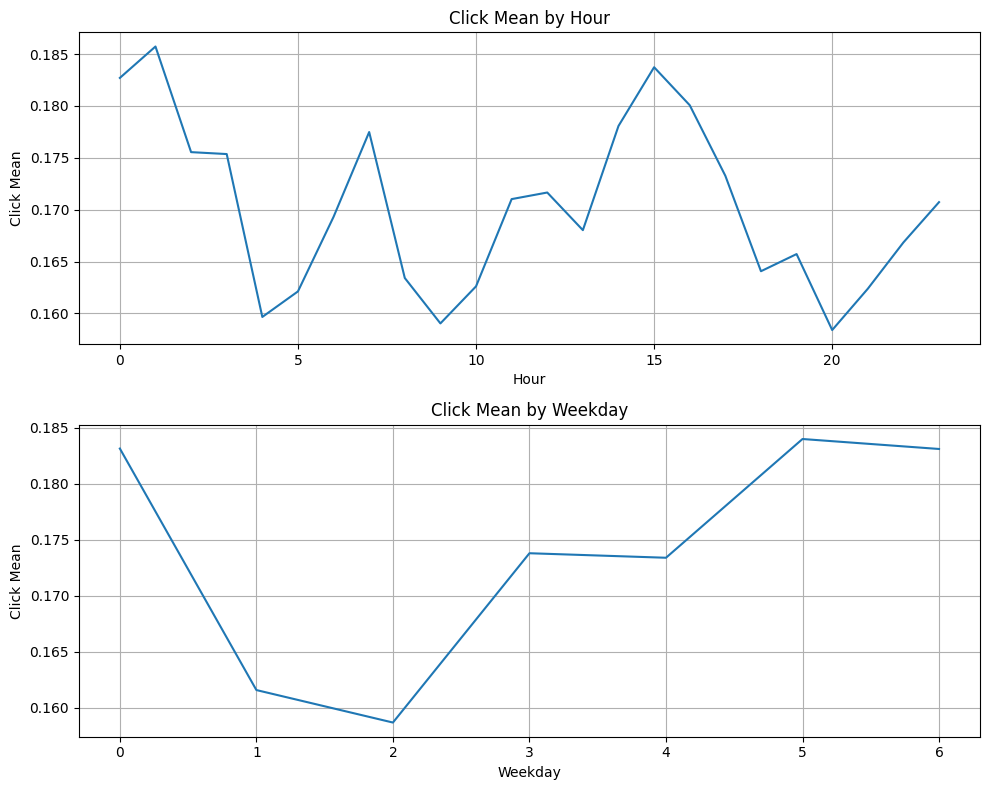

In [12]:
hourclick = df.groupby(['hour'])['click'].mean()
weekdayclick = df.groupby(['weekday'])['click'].mean()

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(10, 8))

# Plot for hour vs click mean
ax[0].plot(hourclick.index, hourclick.values)
ax[0].set_xlabel('Hour')
ax[0].set_ylabel('Click Mean')
ax[0].set_title('Click Mean by Hour')
ax[0].grid(True)

# Plot for weekday vs click mean
ax[1].plot(weekdayclick.index, weekdayclick.values)
ax[1].set_xlabel('Weekday')
ax[1].set_ylabel('Click Mean')
ax[1].set_title('Click Mean by Weekday')
ax[1].grid(True)

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

# Preliminary work and first model

Start by understanding the features with few modalities:
'hour', 'weekday', 'C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C21'.

<font color="red">**Question:**
    For instance, inspect the columns 'C15' (dimension of the advert) and 'site_category': visualize the clicks mean.
</font>

In [13]:
# Fill here: inspect 'C15' using '.groupby'
print(df.groupby(['C15'])['click'].mean())

C15
120     0.033708
216     0.129612
300     0.360537
320     0.158767
480     0.285714
728     0.054144
768     0.375000
1024    0.166667
Name: click, dtype: float64


In [14]:
# Fill here: inspect 'site_category' using '.groupby'
print(df.groupby(['site_category'])['click'].mean())

site_category
0569f928    0.053613
28905ebd    0.208076
335d28a8    0.089824
3e814130    0.284245
42a36e14    0.225806
50e219e0    0.128597
5378d028    0.000000
70fb0e29    0.144737
72722551    0.059172
75fa27f6    0.111305
76b2941d    0.035756
8fd0aea4    0.015873
9ccfa2ea    0.000000
a818d37a    0.000000
bcf865d9    0.000000
c0dd3be3    0.128655
c706e647    0.000000
da34532e    0.000000
dedf689d    0.530449
e787de0e    0.000000
f028772b    0.179719
f66779e6    0.034564
Name: click, dtype: float64


<font color="red">**Question:**
    Some site categories have a null click rate. Why? Display the 'count()' of each modality.
    <br><br>
    Hint: you can use the method ".value_counts()"
</font>

In [15]:
df['site_category'].value_counts() # Fill here

,count
site_category,
50e219e0,408921
f028772b,313339
28905ebd,182020
3e814130,75667
f66779e6,6365
75fa27f6,4007
335d28a8,3351
76b2941d,2573
c0dd3be3,1026


It is practical to visualize both columns in parallel:

In [16]:
col = 'site_category'
a = pd.DataFrame([df.groupby(col)['click'].mean(), df.groupby(col)['click'].count()]).transpose()
a.columns = ['mean', 'count']
a.sort_values(by='count', ascending=False)

,mean,count
site_category,,
50e219e0,0.128597,408921.0
f028772b,0.179719,313339.0
28905ebd,0.208076,182020.0
3e814130,0.284245,75667.0
f66779e6,0.034564,6365.0
75fa27f6,0.111305,4007.0
335d28a8,0.089824,3351.0
76b2941d,0.035756,2573.0
c0dd3be3,0.128655,1026.0


Your answer here

The sites with negligible click rates are the ones that have least occurences.

<font color="red">**Question:**
    Divide the dataset into a training and test set with sklearn (use the following options: test_size=0.1, random_state=100).
    <br>
    Warning: do not use 'id' as a feature.
</font>

In [17]:
from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop(['id', 'click'], axis=1), df['click'], test_size=0.1, random_state=100)

# First work on a reduced number of features

<font color="red">**Question:**
    Put in a list the selected columns: 'hour', 'weekday', 'C1', 'banner_pos', 'site_category', 'app_category', 'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C21'.
</font>

In [18]:
some_columns = ['hour', 'weekday', 'C1', 'banner_pos', 'site_category', 'app_category',
                'device_type', 'device_conn_type', 'C15', 'C16', 'C18', 'C21']

<font color="red">**Question:**
    <br>
    - Import OneHotEncoder from sklearn.preprocessing
    <br>
    - Transform the training and the test data restricted to the selected columns
</font>

In [19]:
from sklearn.preprocessing import OneHotEncoder
ohe = OneHotEncoder(handle_unknown="ignore")
# fit the transformation of Xtrain restricted to selected columns
Xtrain_oh = ohe.fit_transform(Xtrain[some_columns])
# and transform Xtest restricted to selected columns
Xtest_oh = ohe.transform(Xtest[some_columns])

<font color="red">**Question:**
    What is the new number of features?
</font>

In [20]:
Xtrain_oh.shape[1]

183

Your answer here

The new number of features is 183.

<font color="red">**Question:**
    Visualize the first row of the design matrix you have got. Do not forget to convert it into a "numpy.array" using the method ".toarray()".
</font>

In [21]:
Xtrain_oh[0].toarray()

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0.]])

<font color="red">**Question:**
    Import and fit a logistic regression model on your the encoded data.
</font>

In [22]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression('l2')
lr.fit(Xtrain_oh, ytrain)

LogisticRegression()

<font color="red">**Question:**
    With '.predict' and 'predict_proba', display the hard and soft decision you get on test data.
</font>

In [23]:
hard = lr.predict(Xtest_oh)
soft = lr.predict_proba(Xtest_oh)

<font color="red">**Question:**
    Compute the probability of error using sklearn.metrics 'accuracy_score' function. Comment.
</font>

In [24]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(ytest, hard)
print(f"Accuracy: {accuracy}")

Accuracy: 0.83045


Your answer here

The accuracy is good for a preliminary model. Also, since it is not a critical application, 83% is a good accuracy.

<font color="red">**Question:**
    Plot the ROC curve. Then compute the log loss and the Area Under the Curve ROC.
</font>

In [25]:
ytest

,click
617759,1
693227,1
906065,1
828507,1
869730,0
...,...
599633,0
103907,0
536846,1
68354,0


Text(0.5, 1.0, 'ROC curve')

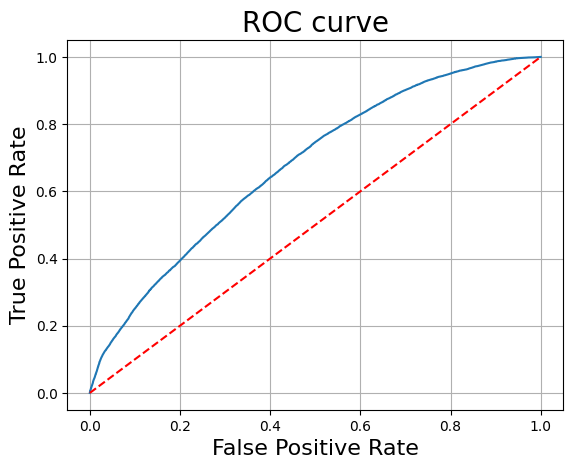

In [26]:
from sklearn.metrics import roc_curve

false_pos_rate, true_pos_rate, _ = roc_curve(ytest, soft[:, 1])
plt.plot(false_pos_rate, true_pos_rate)

plt.grid()
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve', fontsize=20)

In [27]:
from sklearn.metrics import log_loss , roc_auc_score

log_loss(ytest, soft[:,1]), roc_auc_score(ytest, soft[:,1])

(0.4251789966303642, np.float64(0.676061763713435))

# Complete model

As an example, we now focus on the 'site_id' column.

<font color="red">**Question:**
    <br>
    - For each modality, compute the number of occurrences in the dataset and the average of clicks for this modality
    <br>
    - With 'sns.joiplot', represent the set of points (count, mean) for each modality
</font>

In [28]:
import seaborn as sns

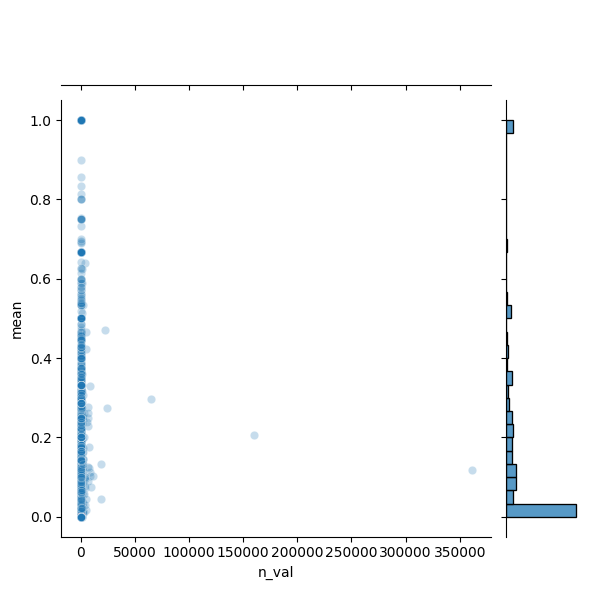

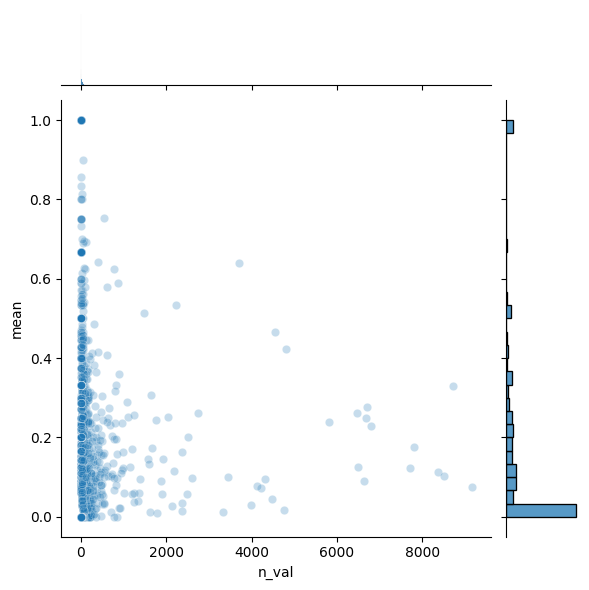

In [29]:
col = 'site_id'
a = pd.DataFrame([df.groupby(col)['click'].mean(), df.groupby(col)['click'].count()]).transpose()
a.columns = ['mean', 'n_val']
sns.jointplot(x=a['n_val'], y=a['mean'], alpha=0.25);
thres = 10000
sns.jointplot(x=a[a['n_val']<thres]['n_val'], y=a[a['n_val']<thres]['mean'], alpha=0.25);

<font color="red">**Question:**
    In the above commands, what does the alpha parameter stand for?
</font>

Your answer here

The alpha stands for the transparence of points.

Several sites with a lot of occurrences in the dataset have a click frequency very different from the mean. It is relevant to keep the column 'site_id' at least for the modalities for which 'count' is very high.

<font color="red">**Question:**
    Do the same work on the 'device_id' column. What do you notice? What could be the isolated point?
</font>

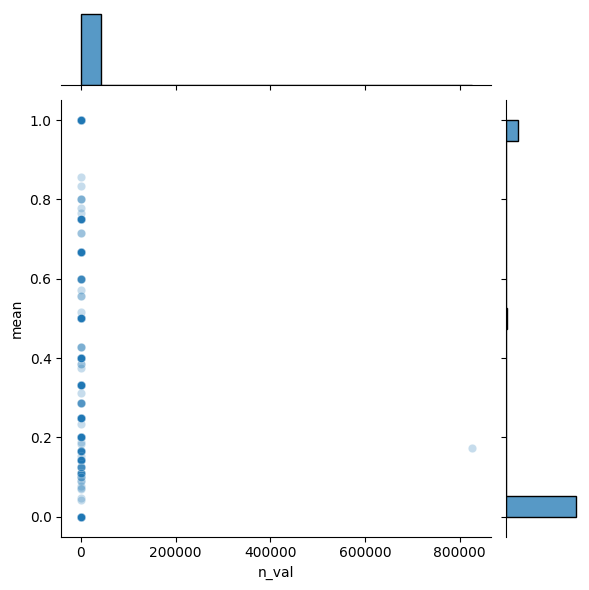

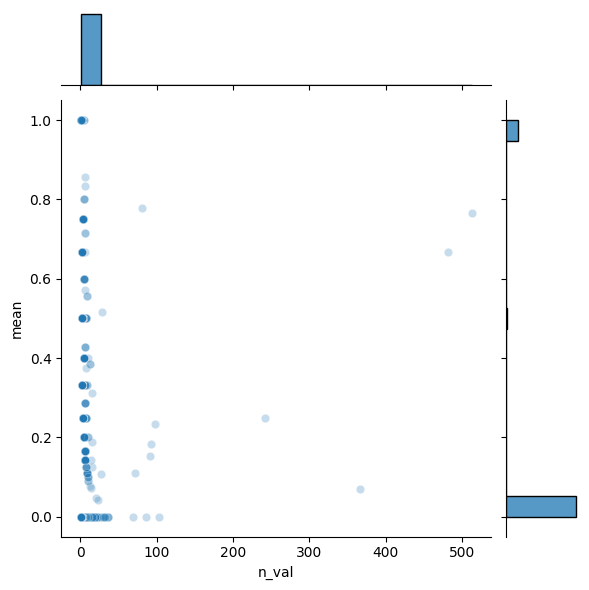

In [30]:
col = 'device_id'
a = pd.DataFrame([df.groupby(col)['click'].mean(), df.groupby(col)['click'].count()]).transpose()
a.columns = ['mean', 'n_val']
sns.jointplot(x=a['n_val'], y=a['mean'], alpha=0.25);
thres = 10000
sns.jointplot(x=a[a['n_val']<thres]['n_val'], y=a[a['n_val']<thres]['mean'], alpha=0.25);

Your answer here

The isolated point is an outlier of a device.

<font color="red">**Question**:   
    In the column df['device_id'], spot the value V corresponding to the largest number of 'count' (using '.value_counts' method). Create a new column df['user'] defined as follows:
</font>
$$
\text{user} = \left\{\begin{array}[h]{ll} \text{device_ip + device_model} & \text{if device_id = V}\\ \text{device_id} & \text{else.}\end{array}\right.
$$

In [31]:
V = df['device_id'].value_counts().index[0]
df['user'] = (df['device_ip'] + df['device_model']) * (df['device_id']==V) + df['device_id'] * (df['device_id']!=V)

<font color="red">**Question**:
    Drop in place the following columns: 'device_id', 'device_model' and 'device_ip'
</font>

In [32]:
df.drop(columns=['device_id', 'device_model', 'device_ip'], inplace=True) #Fill here

<font color="red">**Question**:
    One could look at the similarity between 'site_id' and 'site_domain'. Merge those columns into a new 'site' column (using the '+' operator)  and delete the old 'site_id' and 'site_domain' columns.
</font>

In [33]:
df['site'] = df['site_id'] + df['site_domain']
df.drop(columns=['site_id', 'site_domain'], inplace=True) #Fill here

<font color="red">**Question**:
    Once again, split the modified DataFrame 'df' into a train and a test set (with options: test_size=0.1 and random_state=100).
    <br>
    Warning: do not use 'id' as a feature.
</font>

In [34]:
Xtrain, Xtest, ytrain, ytest = train_test_split(df.drop(columns=['id', 'click']), df['click'], test_size=0.1)

<font color="red">**Question**:
    Define a OneHotEncoder and then, 'fit_transform' the train set.
</font>

In [35]:
ohe = OneHotEncoder(handle_unknown='ignore')
# Fill here
Xtrain_oh = ohe.fit_transform(Xtrain)

<font color="red">**Question**:
    Transform the test set. If an error occurs, analyze it and try to solve it by modifying the parameter "handle_unkown" of the OneHotEncoder.
    <br>
    Explain your the problem you encouter and how you solved it.
</font>

In [36]:
# Fill here
Xtest_oh = ohe.transform(Xtest)

Your answer here

At first, I got a value error because OHE found unknown categories. To solve this, we need to set handle_unknown='ignore' so whenever it founds a unknown category, it just creates a column of zeros.

<font color="red">**Question**:
    What is the new number of features?
</font>

In [37]:
Xtrain_oh.shape[1]

713344

Your answer here

The number of features is equal to 713309.

<font color="red">**Question**:
    How many modalities have been seen more than a 100 times?
</font>

In [38]:
# The following 'n_ones' vector below gives the number of '1' in each column of the Xtrain_oh design matrix.
n_ones = np.array(Xtrain_oh.sum(axis=0))
 # Fill here using 'n_ones'
big_n_ones = n_ones[n_ones>100]
len(big_n_ones)

1974

Your answer here

1974  modalities were seen more than a 100 times.

The list 'cols_to_keep' below is used to store the indices of the modalities seen more than a 100 times.

<font color="red">**Remark**:
    Note how the `enumerate` function works
</font>

In [39]:
useful = np.array(n_ones>100)[0]
cols_to_keep = [i for i,b in enumerate(useful) if b]

Your answer here

Enumerate function create tuples (i, b) where i is the index of the element in "useful" and b is the value of the element stored in position "i".

<font color="red">**Question**:
    Using only our restriction on the 'cols_to_keep' columns, retrain a logistic regression model and compare its performance in terms of 'log_loss' and 'roc_auc_curve'.
</font>

In [40]:
lr = LogisticRegression()
#fit on only cols_to_keep columns
lr.fit(Xtrain_oh[:, cols_to_keep]  , ytrain)
hard = lr.predict(Xtest_oh[:, cols_to_keep])
soft = lr.predict_proba(Xtest_oh[:, cols_to_keep])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [41]:
#compute log loss and roc_auc_curve
log_loss(ytest, soft[:,1]), roc_auc_score(ytest, soft[:,1])

(0.40608595024976013, np.float64(0.7339392941923234))

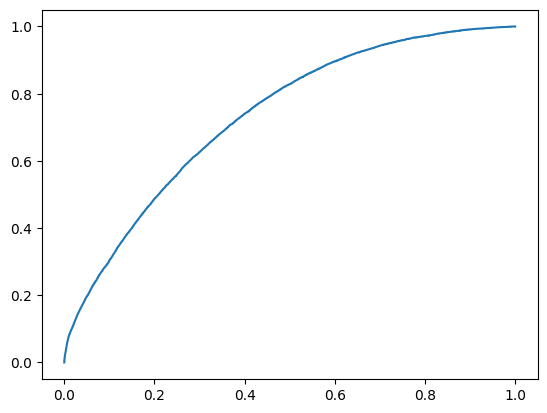

In [42]:
#plot auc curve
false_pos_rate, true_pos_rate, _ = roc_curve(ytest, soft[:, 1])
plt.plot(false_pos_rate, true_pos_rate)

Answers:

Results from first model:
(0.4251789966303642, np.float64(0.676061763713435)).

Results from second model:
(0.40608595024976013, np.float64(0.7339392941923234))

The second model had an improvement by probably removing noise from instances that does not appear frequently.

# Gradient Boosting Decision Trees

<font color="red">**Question**:
    <br>
    - Import GradientBoostingClassifier from scikit learn.
    <br>
    - Initialize it using 50 estimators and a learning rate of 0.8. Set 'verbose=True' to monitor the progress of the training step.
    <br>
    - Fit it on the same columns 'cols_to_keep' of Xtrain_oh than for the previous logistic regression.
    <br>
    - Evaluate its performance as in the previous step.
</font>

In [43]:
from sklearn.ensemble import GradientBoostingClassifier
# Fill here
gb = GradientBoostingClassifier(n_estimators=50, learning_rate=0.8, verbose=True)

In [44]:
gb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

      Iter       Train Loss   Remaining Time 
         1           0.8737            1.47m
         2           0.8639            1.52m
         3           0.8578            1.43m
         4           0.8528            1.34m
         5           0.8497            1.27m
         6           0.8464            1.22m
         7           0.8446            1.18m
         8           0.8429            1.14m
         9           0.8406            1.11m
        10           0.8386            1.11m
        20           0.8272           54.51s
        30           0.8216           38.65s
        40           0.8177           21.02s
        50           0.8153            0.00s


GradientBoostingClassifier(learning_rate=0.8, n_estimators=50, verbose=True)

In [45]:
soft = gb.predict_proba(Xtest_oh[:,cols_to_keep])
log_loss(ytest, soft[:, 1]), roc_auc_score(ytest, soft[:, 1])

(0.4114938623249806, np.float64(0.7235702387936574))

<font color="red">**Question**:
    What does the 'gb.estimators_' output?
</font>

In [46]:
gb.estimators_

array([[DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x782714CC2140)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x782714CC2140)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x782714CC2140)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x782714CC2140)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x782714CC2140)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
                              random_state=RandomState(MT19937) at 0x782714CC2140)],
       [DecisionTreeRegressor(criterion='friedman_mse', max_depth=3,
       

Your answer here

gb.estimators_ outputs all the individual weak learners that form the ensemble. Since we are in a GradientBoostingClassifier case, these learners are DecisionTreeRegressors.

We now try to use the 'gb' classifier to generate features that will be relevant inputs for the logistic regression.

<font color="red">**Question**:
    With the 'gb.apply()' method, generate a transformation 'leafs_train' of the training set 'Xtrain_oh[:, cols_to_keep]' for which the n-th column corresponds to the number of the leaf returned by the estimator n.
</font>

In [47]:
# Test here the gb.apply method on Xtrain[:, cols_to_keep]

leafs_train_oh = gb.apply(Xtrain_oh[:, cols_to_keep])
leafs_train_oh.shape

(900000, 50, 1)

After your applied gb.apply on Xtrain_oh[:, cols_to_keep], remember that we have only one class to predict (click = 0 or 1). So, do not forget to slice your output with [:, :, 0] in order to keep, firstly, all the samples, and secondly all your 50 estimators.

Hint: you can have a look at the dimensions of your output with .shape !

In [48]:
#fill here
leafs_train_oh = leafs_train_oh[:,:,0]
leafs_train_oh.shape

(900000, 50)

<font color="red">**Question**:
    Encode these new features into dummies.
</font>

In [49]:
 # Fill here an argument if needed
ohe = OneHotEncoder( handle_unknown='ignore')
leafs_train_oh = ohe.fit_transform(leafs_train_oh)
leafs_test_oh = ohe.transform(gb.apply(Xtest_oh[:, cols_to_keep])[:,:,0])

<font color="red">**Question**:
    With the "hstack" function, create a new matrix of features by concatenating horizontally our new features "leafs_train_oh" and "leafs_test_oh", and previous features used for logistic regression (e.g. in "Xtrain_oh[:, cols_to_keep]").
</font>
<br><br>
**Remark**: we use "hstack" from scipy.sparse (and not from numpy) because the output of our OneHotEncoder is a sparse array. You can verify it with the command "type(Xtrain_oh)".

In [50]:
from scipy.sparse import csr_matrix, hstack

# Fill here
Xtrain_concat = hstack([ Xtrain_oh[:,cols_to_keep] , leafs_train_oh ])
Xtest_concat = hstack([ Xtest_oh[:,cols_to_keep] , leafs_test_oh ])

<font color="red">**Question**:
    Run a logistic regression on the new features and evaluate its performance as before.
    <br>
    Warning: be patient, fitting should take about 5 minutes on Google Colab.
</font>

In [51]:
lr = LogisticRegression()
lr.fit(Xtrain_concat, ytrain)
soft = lr.predict_proba(Xtest_concat)
log_loss(ytest, soft[:,1]), roc_auc_score(ytest, soft[:,1])

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


(0.40610439766006645, np.float64(0.7341542005532083))

Answers:

Results from first model: (0.4251789966303642, np.float64(0.676061763713435)).

Results from second model: (0.40608595024976013, np.float64(0.7339392941923234))

Results from third model (GB): (0.4114938623249806, np.float64(0.7235702387936574))

Results from fourth model : (0.40610439766006645, np.float64(0.7341542005532083))

Slight improvement, but not significant.



# XGBoost

<font color="red">**Question**:
    <br>
    - Import XGBClassifier from xgboost package.
    <br>
    - Initialize it using the same number of estimators and learning rate as before. Set the 'n_jobs' to -1.
    <br>
    - Fit it on the same columns 'cols_to_keep' of Xtrain_oh than for the previous logistic regression.
    <br>
    - Evaluate its performance and compare it to the GradientBoosting classifier of scikit learn. How is the error? Does it take more time to run?
</font>

In [52]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=50, learning_rate=0.8, n_jobs=-1, verbosity=2)
%time xgb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

[17:04:43] INFO: /workspace/src/data/iterative_dmatrix.cc:56: Finished constructing the `IterativeDMatrix`: (900000, 1974, 17007966).
CPU times: user 8.77 s, sys: 553 ms, total: 9.32 s
Wall time: 5.46 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.8, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=50,
              n_jobs=-1, num_parallel_tree=None, ...)

In [53]:
#compute metrics
soft = xgb.predict_proba(Xtest_oh[:,cols_to_keep])
log_loss(ytest, soft[:, 1]), roc_auc_score(ytest, soft[:, 1])

(0.4068170312080153, np.float64(0.732807811170552))

Results from third model (GB): (0.4114938623249806, np.float64(0.7235702387936574))

Results from XGB: (0.4068170312080153, np.float64(0.732807811170552))

Pratically the same results but much more faster.

<font color="red">**Question**:
    Increase the number of estimators and visualize the impact on performance. You might have to adapt the learning rate. On Google Colab, here are the approximate training times<br>
    - nb_estimators=256  and lr=0.8 ~  4 min<br>
    - nb_estimators=512  and lr=0.6 ~  8 min<br>
    - nb_estimators=1024 and lr=0.5 ~ 16 min
</font>

In [57]:
xgb = XGBClassifier(n_estimators=512, learning_rate=0.8, n_jobs=-1, verbosity=1)
%time xgb.fit(Xtrain_oh[:,cols_to_keep], ytrain)

CPU times: user 1min 10s, sys: 364 ms, total: 1min 10s
Wall time: 51 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.8, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=512,
              n_jobs=-1, num_parallel_tree=None, ...)

In [58]:
#compute metrics
soft = xgb.predict_proba(Xtest_oh[:,cols_to_keep])
log_loss(ytest, soft[:, 1]), roc_auc_score(ytest, soft[:, 1])

(0.40691643131989896, np.float64(0.7349938381513008))

Results from third model (GB): (0.4114938623249806, np.float64(0.7235702387936574))

Results from XGB: (0.4068170312080153, np.float64(0.732807811170552))

Results XGB 512 estimators: 0.40691643131989896, np.float64(0.7349938381513008))



# Features hashing and random forest

We restart with raw features before dummy encoding: Xtrain, Xtest.

<font color="red">**Question**:
    Display again the number of modalities per feature in Xtrain. Use '.nunique()'
</font>

In [59]:
# Fill here
Xtrain.nunique()

,0
hour,24
C1,7
banner_pos,7
site_category,22
app_id,3047
app_domain,189
app_category,26
device_type,5
device_conn_type,4
C14,2216


We want to define a transformation which regroups the least frequent modalities into a label 'isRare'. In order to do so, we decide to define our own Transformer.

<font color="red">**Question**:
    Understand the different steps of 'fit' and 'transform'.
</font>

In [60]:
from sklearn.base import BaseEstimator, TransformerMixin

class MergeRareTransformer(BaseEstimator, TransformerMixin):

    def __init__(self, col_names, threshold):
        self.col_names = col_names
        self.threshold = threshold

    def fit(self, X, y=None):

        X = pd.DataFrame(X)
        counts_dict_list = []
        ################## READ THIS #########################
        for i in range(len(self.col_names)):

            serie = X[self.col_names[i]].value_counts()  # Série des counts de chaque modalité
            rare_indexes = serie[serie<self.threshold[i]].index  # A quoi correspondent ces indices ?
            frequent_indexes = serie[serie>=self.threshold[i]].index  # A quoi correspondent ces indices ?
            dico = {x:'isRare' for x in rare_indexes}
            dico.update({x: str(x) for x in frequent_indexes})
            counts_dict_list.append(dico)   # Quel est le dictionnaire obtenu ?

        ######################################################

        self.counts_dict_list_ = counts_dict_list
        return self

    def transform(self, X):

        Xt = pd.DataFrame()
        ################## READ THIS #########################
        for col, count_dict in zip(self.col_names, self.counts_dict_list_):
            Xt[col] = X[col].apply(lambda x:count_dict[x] if x in count_dict else 'isRare')
            # A quoi sert le "else 'isRare'" dans la transformation de la colonne ?
        ######################################################

        return Xt


Answers:

These indices correspond to the modalities (categories) of the column that appear less than the threshold number of times.

These indices correspond to the modalities that appear frequently enough (>= threshold).

For each column, dico maps Rare categories ('isRare') and Frequent categories (their own name as string).



<font color="red">**Question:**
    <br>
    - Fit and transform the training set. To do so, merge all mmodalities occuring at least 20 times in each column.
    <br>
    - Transform the test set.
</font>

In [61]:
mg = MergeRareTransformer(col_names=Xtrain.columns, threshold=[20]*len(Xtrain.columns))
# Fill here with fit_transform
Xtrain_mg = mg.fit_transform(Xtrain)
# Fill here with transform
Xtest_mg = mg.transform(Xtest)

<font color="red">**Question:**
   How many elements of the column Xtrain_mg['app_domain'] are now labeled as 'rare'? Use the '.value_counts()' method.
</font>

In [63]:
# Fill here
Xtrain_mg['app_domain'].value_counts()

,count
app_domain,
7801e8d9,606253
2347f47a,116464
ae637522,42015
5c5a694b,25206
82e27996,16826
d9b5648e,15833
0e8616ad,14918
b9528b13,14293
b8d325c3,11901


Answer:

496 rare instances.

<font color="red">**Question:**
   In the new train set, display the number of modalities for each feature.
</font>

In [64]:
# Fill here
Xtrain_mg.nunique()

,0
hour,24
C1,7
banner_pos,7
site_category,18
app_id,614
app_domain,53
app_category,19
device_type,5
device_conn_type,4
C14,1332


Modalities are arbitrary object, such as '234', 'isRare', etc. We will now transorm them into integers with the hashing trick.

<font color="red">**Question:**
   To better understand how the 'hash' function is working, apply it to a string of your choice.
</font>

In [65]:
import hashlib
# Fill here
hash('my_test_string')

-8747017856251563850

<font color="red">**Question:**
   Create two new datasets 'Xtrain_ha' and 'Xtest_ha' containing the output of the hashing process. Use the '.apply' method to transform iteratively the columns by mapping to each value its remainder in the euclidean division of the hash by 1000000.
   Example:
</font>
</font>
<p>
<center>
2060777048690<font color="red">918393</font>  -->  918393
</center>
Remark: do not forget that the function 'hash' has to take a string as input.

In [66]:
Xtrain_ha = pd.DataFrame()
Xtest_ha = pd.DataFrame()
for col in Xtrain_mg.columns:
    Xtrain_ha[col] = Xtrain_mg[col].apply(lambda x: abs(hash(str(x))) % 1000000) # Fill here defining a lambda function
    Xtest_ha[col] = Xtest_mg[col].apply(lambda x: abs(hash(str(x))) % 1000000)

<font color="red">**Question:**
   Visualize the content of the DataFrames you have obtained.
</font>

In [67]:
print('Xtrain_ha head:')
print(Xtrain_ha.head())
print('\nXtest_ha head:')
print(Xtest_ha.head())

Xtrain_ha head:
          hour      C1  banner_pos  site_category  app_id  app_domain  \
683683  204362  664052      443927         799102  240636      696532   
352975   34307  664052      752934         799102  240636      696532   
503783  752934  664052      443927         152970  626814      393076   
583287  208039  664052      752934         152970  835997      393076   
236490   41157  664052      443927         898314  240636      696532   

        app_category  device_type  device_conn_type     C14     C15     C16  \
683683        680219       752934            443927  471325  702876   82635   
352975        680219       752934            443927  974182  102696  600695   
503783        265141       752934            270539  306678  102696  600695   
583287        265141       752934            443927  257937  102696  600695   
236490        680219       752934            443927   91681  102696  600695   

           C17     C18     C19     C20     C21  weekday    user    sit

<font color="red">**Question:**
    <br>
    - Train a RandomForestClassifier on Xtrain_ha and evaluate its performance on Xtest_ha. Chose 256 estimators, min_samples_leaf=20 and verbose=1 in order to monitor the fitting step. (If you have enough time, try later with 1024 estimators and min_samples_leaf=20).
    <br>
    - How do you fix 'n_jobs'?
</font>

In [68]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=256, min_samples_leaf=20, n_jobs=-1, verbose=1)
rf.fit(Xtrain_ha, ytrain)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=-1)]: Done  46 tasks      | elapsed:   48.8s
[Parallel(n_jobs=-1)]: Done 196 tasks      | elapsed:  4.0min
[Parallel(n_jobs=-1)]: Done 256 out of 256 | elapsed:  5.1min finished


RandomForestClassifier(min_samples_leaf=20, n_estimators=256, n_jobs=-1,
                       verbose=1)

In [70]:
soft = rf.predict_proba(Xtest_ha)
log_loss(ytest, soft[:,1]), roc_auc_score(ytest, soft[:,1])

[Parallel(n_jobs=2)]: Using backend ThreadingBackend with 2 concurrent workers.
[Parallel(n_jobs=2)]: Done  46 tasks      | elapsed:    1.4s
[Parallel(n_jobs=2)]: Done 196 tasks      | elapsed:    4.5s
[Parallel(n_jobs=2)]: Done 256 out of 256 | elapsed:    6.0s finished


(0.4046263395369768, np.float64(0.7380064764858393))

Answer:

Set n_jobs = -1 to use all available CPU cores.

<font color="red">**Question:**
   Compare with xgboost performance on the same hashed dataset, with n_estimators=256, n_jobs=-1, learning_rate=1.0. (If you have enough time try n_estimators=1024, n_jobs=-1, learning_rate=0.5, it will perform better than a Random Forest of 1024 trees).
</font>

In [71]:
from xgboost import XGBClassifier

xgb = XGBClassifier(n_estimators=256, n_jobs=-1, learning_rate=1.0, verbosity=1)
%time xgb.fit(Xtrain_ha, ytrain)

CPU times: user 31.1 s, sys: 118 ms, total: 31.2 s
Wall time: 18 s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=1.0, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=256,
              n_jobs=-1, num_parallel_tree=None, ...)

<font color="red">**Question:**
    Plot the ROC curve for the obtained classifier (xgboost on hashed data).
</font>

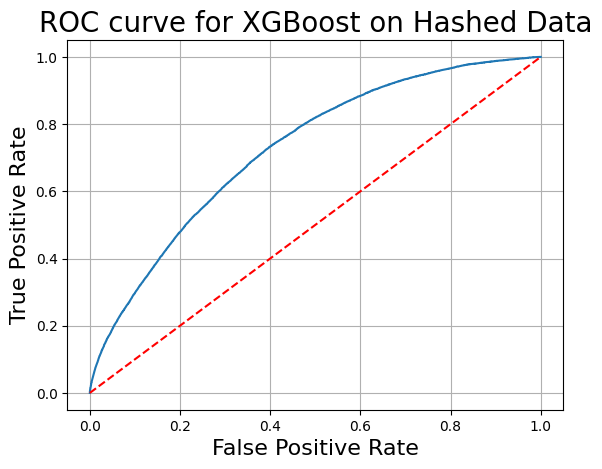

In [72]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

soft = xgb.predict_proba(Xtest_ha)
false_pos_rate, true_pos_rate, _ = roc_curve(ytest, soft[:, 1])
plt.plot(false_pos_rate, true_pos_rate)

plt.grid()
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate', fontsize=16)
plt.ylabel('True Positive Rate', fontsize=16)
plt.title('ROC curve for XGBoost on Hashed Data', fontsize=20)
plt.show()

In [73]:
#compute metrics
log_loss(ytest, soft[:, 1]), roc_auc_score(ytest, soft[:, 1])

(0.41433030755252503, np.float64(0.7262619784773598))

Your answer here

All classifier metrics are really similiar one to another, no significant performance gains. The best classifier was maybe logistic regression with new features generated by gradient boost leafs, due its balance between loss and auc.

Good job! :-)

<font color="red">**Bonus Question:**
    If you have enough time (about 2 hours ...), try to fit both random forest and xgboost models with more estimators (and a different learning rate of 0.5 for xgboost) on these enlarged datasets.<br>
</font>

In [ ]:
# Fill here

# BONUS : Field-aware Factorization Machines
<br>
<font color="red">
Display the names of the columns of the matrix Xtrain_ha
</font>

<font color="red">
Create a list of lists of the columns. The n-th sub-list is composed of the names of the columns of the n-th field.</font>

In [ ]:
fields = []
fields.append( liste_colonnes_du_premier_champ )
fields.append( liste_colonnes_du_deuxième_champ )
fields.append( etc. )


<font color="red">
With the enumerate function, let generate a dictionary which associates each column name with its field.


In [ ]:
dicFields = { ... : ...  for i,f in enumerate(fields) for name_col in f}

We need to make sure that two different columns have different modalities. For this, we add in front of each modality a characteristic string of the column.

<font color="red">Perform this transformation with the apply method</font>


In [ ]:
Xtrain_ffm = pd.DataFrame()
Xtest_ffm = pd.DataFrame()
for col in Xtrain_ha.columns:
    Xtrain_ffm[col] = Xtrain_ha[col].apply( ... )
    Xtest_ffm[col] = Xtest_ha[col].apply( ... )

With np.unique, we create the list of all the modalities appearing in all the columns.

In [ ]:
allvals = []
allcols_ffm = [col for f in fields for col in f]  # Toutes les colonnes appartenant à l'un des champ
for col in allcols_ffm:
    allvals.append(np.unique(Xtrain_ffm[col]))
allvals= [val for sublist in allvals for val in sublist]

<font color="red">
Using enumerate method, create a dictionary that at each value associates its rank in the allvals list.</font>

In [ ]:
dicFeat = {val:i for i,val in ... }

We build dataframe from dicFeat as follows:
in each "col" column, the value "x" is replaced by the string "f: v: 1", where f is the field associated with the column and v is the index of the modality x.
<font color="red">
Study the following code</font>

In [ ]:
for col in allcols_ffm:
    f = dicFields[col]
    Xtrain_ffm[col] = Xtrain_ffm[col].apply(lambda x:"{}:{}:1".format(f,dicFeat[x]) if x in dicFeat else "")
    Xtest_ffm[col] = Xtest_ffm[col].apply(lambda x:"{}:{}:1".format(f,dicFeat[x]) if x in dicFeat else "")

<font color="red">For the two resulting dataframes, concatenate on the left the corresponding ytrain (or ytest) click column</font>

In [ ]:
yXtrain_ffm = pd.concat( ... ,axis=1)
yXtest_ffm = pd.concat( ... ,axis=1)

<font color="red">What does the following cell produce?</font>

In [ ]:
train_w = yXtrain_ffm.apply(lambda row:' '.join(row.values),axis=1).values
test_w = yXtest_ffm.apply(lambda row:' '.join(row.values),axis=1).values

<font color="red">Write the above dataframe in a text file</font>

In [ ]:
thefile = open('train.txt','w')
for item in train_w:
    thefile.write("%s\n" % item)

# Faire de même pour le test set


To learn the FFM model, we use the LibFFM library https://www.csie.ntu.edu.tw/~cjlin/libffm/
In the notebooks / directory there are two executables: ffm-train and ffm-predict.
In jupyter notebook, the exclamation point! allows to launch a bash command.
The use is as follows:

-   `ffm-train'

    usage: ffm-train [options] training_set_file [model_file]

    options:  
    -l <lambda>: set regularization parameter (default 0.00002)  
    -k <factor>: set number of latent factors (default 4)  
    -t <iteration>: set number of iterations (default 15)  
    -r <eta>: set learning rate (default 0.2)  
    -s <nr_threads>: set number of threads (default 1)  
    -p <path>: set path to the validation set  
    --quiet: quiet model (no output)  
    --no-norm: disable instance-wise normalization  
    --auto-stop: stop at the iteration that achieves the best validation loss (must be used with -p)  
<br>
<font color="red">Learn the model. We can :
- use an regularizer of 0.00001
- use a learning rate of 0.05
- use of the order of 15 latent factors
- carry out the order of 30 iterations
- with the -p option, change the test file to validation parameters
- activate the --autostop mode
</font>

The use of ffm-predict is: ffm-predict filename-test file-name-model file-in-which-write-the-prediction
<font color="red">Perform the prediction</font>

<font color="red">Compute the log_loss and area under the roc curve (ROC AUC).</font>

# Bonus 2 : blending

<font color="red">
Split Xtrain in two: Xtrain_meth and Xtrain_blend.</font>

In [ ]:
Xtrain_meth, Xtrain_blend, ytrain_meth, ytrain_blend = train_test_split(Xtrain_ha,ytrain,test_size=0.2)

<font color="red">
Train a logistic regression on XTrain_meth. Then compute its score on Xtrain_blend and save the score in a vector.</font>

<font color="red">
Do the same thing with XGBoost (save the score).</font>

<font color="red">
Do the same with a RandomForest (save the score).</font>

<font color="red">
Now with an extraTrees.</font>

<font color="red">
And again with FFM.</font>

<font color="red">
Concatenate all scores on Xtrain_blend to form a Zblend design matrix.</font>

<font color="red">
Train a logistic regression on (Zblend,ytrain_blend).</font>

<font color="red">
Evaluate the performance of this model on the test dataset.</font>